IRIS DATASET
Linear Accuracy: 1.0
Confusion Matrix: [[0, 0], [0, 30]]
RBF Accuracy: 1.0
Confusion Matrix: [[0, 0], [0, 30]]

LETTER DATASET
Accuracy: 0.5495
Confusion Matrix: [[959, 780], [1022, 1239]]
AUC: 0.5315302206024095


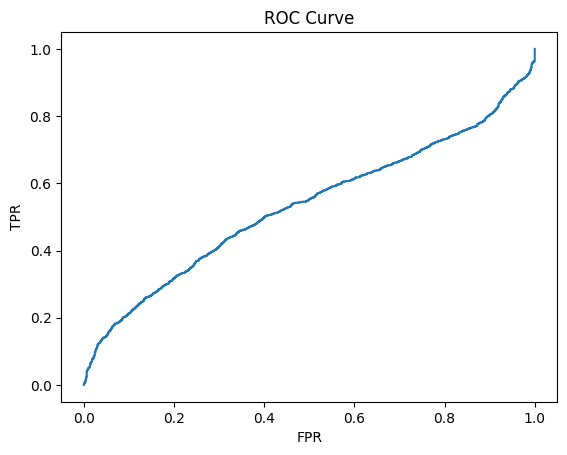

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

def train_svm(X, y, lr=0.001, lambda_param=0.01, epochs=1000):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        for i in range(len(X)):
            condition = y[i] * (np.dot(X[i], w) + b) >= 1

            if condition:
                w -= lr * (2 * lambda_param * w)
            else:
                w -= lr * (2 * lambda_param * w - y[i] * X[i])
                b -= lr * y[i]

    return w, b


def predict(X, w, b):
    return np.sign(np.dot(X, w) + b)


def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


def confusion_matrix_manual(y_true, y_pred):
    TP = TN = FP = FN = 0

    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == -1 and y_pred[i] == -1:
            TN += 1
        elif y_true[i] == -1 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == -1:
            FN += 1

    return [[TP, FP], [FN, TN]]


def rbf_transform(X):
    return np.c_[X, X[:,0]**2, X[:,1]**2]


def compute_scores(X, w, b):
    return np.dot(X, w) + b


def roc_curve_manual(y_true, scores):
    # Sort thresholds in descending order to generate FPR and TPR in increasing order
    thresholds = sorted(scores, reverse=True)
    tpr_list = []
    fpr_list = []

    for thresh in thresholds:
        y_pred = np.where(scores >= thresh, 1, -1)

        TP = TN = FP = FN = 0

        for i in range(len(y_true)):
            if y_true[i] == 1 and y_pred[i] == 1:
                TP += 1
            elif y_true[i] == -1 and y_pred[i] == -1:
                TN += 1
            elif y_true[i] == -1 and y_pred[i] == 1:
                FP += 1
            elif y_true[i] == 1 and y_pred[i] == -1:
                FN += 1

        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return fpr_list, tpr_list


def auc_manual(fpr, tpr):
    area = 0
    for i in range(1, len(fpr)):
        area += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2
    return area

# Download the iris.csv file
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
iris_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
response = requests.get(iris_url)
with open("iris.csv", "w") as f:
    f.write(response.text)

print("IRIS DATASET")

data = pd.read_csv("iris.csv", names=iris_columns)
data['species'] = data['species'].apply(lambda x: 1 if x == 'Iris-setosa' else -1)

X = data[['sepal_length', 'sepal_width']].values
y = data['species'].values

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

w, b = train_svm(X_train, y_train)
y_pred = predict(X_test, w, b)

print("Linear Accuracy:", accuracy(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix_manual(y_test, y_pred))

X_train_rbf = rbf_transform(X_train)
X_test_rbf = rbf_transform(X_test)

w, b = train_svm(X_train_rbf, y_train)
y_pred = predict(X_test_rbf, w, b)

print("RBF Accuracy:", accuracy(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix_manual(y_test, y_pred))


print("\nLETTER DATASET")

# Download the letter-recognition.csv file
letter_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
response = requests.get(letter_url)
with open("letter-recognition.csv", "w") as f:
    f.write(response.text)

letter_columns = ['letter'] + [f'x_coord_{i}' for i in range(1, 17)]
data = pd.read_csv("letter-recognition.csv", names=letter_columns)
data['letter'] = data['letter'].apply(lambda x: 1 if x < 'N' else -1)

X = data.drop("letter", axis=1).values
y = data['letter'].values

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

w, b = train_svm(X_train, y_train)
y_pred = predict(X_test, w, b)

print("Accuracy:", accuracy(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix_manual(y_test, y_pred))


scores = compute_scores(X_test, w, b)
fpr, tpr = roc_curve_manual(y_test, scores)
auc_value = auc_manual(fpr, tpr)

print("AUC:", auc_value)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()